In [ ]:
# Connect the drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


Found 330 images belonging to 2 classes.
Found 330 images belonging to 2 classes.
Found 330 images belonging to 2 classes.
Found 330 images belonging to 2 classes.


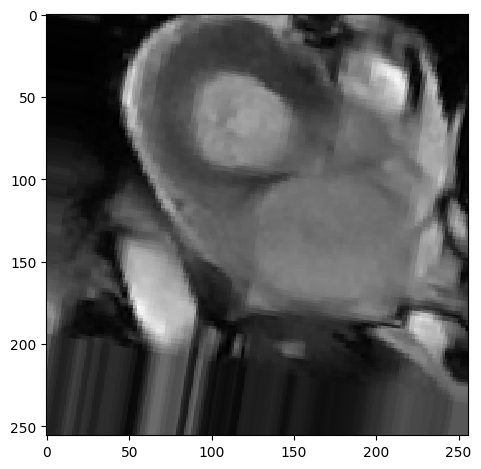

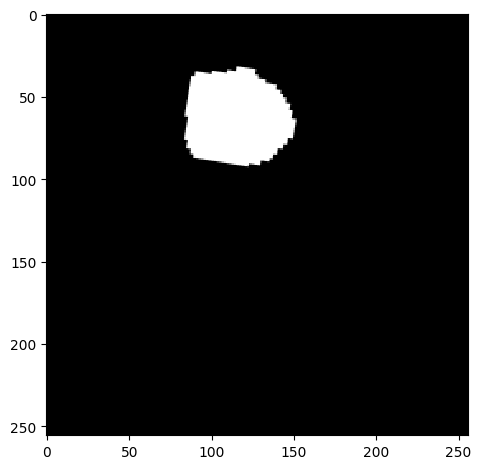

Ellipsis

In [ ]:
#####################################################################
# Create train and validation datasets:                          #
# Image generation and augmentation                                 #
# Build image generators for training / validation images and masks #
# using the flow_from_directory Keras subroutine                    #
#####################################################################

# Import required libraries
import os
import datetime
import numpy as np
from skimage.io import imshow
from matplotlib import pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import CSVLogger
from tensorflow.keras.callbacks import EarlyStopping
import sys

# Paths for train and validation images
DATA_PATH = '/content/drive/MyDrive/ProjetDL2024/Dataset'
TRAIN_FRAME_PATH = os.path.join(DATA_PATH, 'frames')
VAL_FRAME_PATH = os.path.join(DATA_PATH, 'frames')
TRAIN_MASK_PATH = os.path.join(DATA_PATH, 'masks endo')
VAL_MASK_PATH = os.path.join(DATA_PATH, 'masks endo')

# Instances of ImageDataGenerator for training and validation datasets
# Geometrical data augmentation is only considered for the training dataset
# Image gray levels are normalized between 0 and 1
# outputs = train_datagen and val_datagen
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range =10,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True)

val_datagen = ImageDataGenerator(
    rescale=1./255)

BATCH_SIZE = 32  # Power of two: 4/8/16/32/64

# The images must be found in a subdir of TRAIN_FRAME_PATH for instance /Train
# Output = train_image_generator (images from TRAIN_FRAME_PATH)
train_image_generator = train_datagen.flow_from_directory(
    TRAIN_FRAME_PATH,
    target_size=(256,256),
    batch_size=BATCH_SIZE,
    class_mode=None,
    color_mode='grayscale',
    seed=123)

# The images must be found in a subdir of TRAIN_MASK_PATH for instance /Train
# Use the same seed as training images so that augmentation is the same
train_mask_generator = train_datagen.flow_from_directory(TRAIN_MASK_PATH,
                                                          target_size=(256,256),
                                                          batch_size=BATCH_SIZE,
                                                          class_mode=None,
                                                          color_mode='grayscale',
                                                          seed=123)


# The images must be found in a subdir of VAL_FRAME_PATH for instance /Val
# Output = val_image_generator (images from VAL_FRAME_PATH)
val_image_generator = val_datagen.flow_from_directory(VAL_FRAME_PATH,
                                                          target_size=(256,256),
                                                          batch_size=BATCH_SIZE,
                                                          class_mode=None,
                                                          color_mode='grayscale',
                                                          seed=123)

# The images must be found in a subdir of VAL_MASK_PATH for instance /Val
# Use the same seed as validation images so that aumentation is the same
val_mask_generator = val_datagen.flow_from_directory(VAL_MASK_PATH,
                                                          target_size=(256,256),
                                                          batch_size=BATCH_SIZE,
                                                          class_mode=None,
                                                          color_mode='grayscale',
                                                          seed=123)

train_generator = zip(train_image_generator, train_mask_generator)
val_generator = zip(val_image_generator, val_mask_generator)

def train_generator_fn(): # Create a generator function
    for (img, mask) in train_generator:
        yield (img, mask)

def val_generator_fn(): # Create a generator function
    for (img, mask) in val_generator:
        yield (img, mask)

# Convert generators to tf.data.Dataset
train_dataset = tf.data.Dataset.from_generator(
    train_generator_fn,
    output_signature=(tf.TensorSpec(shape=(BATCH_SIZE, 256, 256, 1), dtype=tf.float32),tf.TensorSpec(shape=(BATCH_SIZE, 256, 256, 1), dtype=tf.float32)))

val_dataset = tf.data.Dataset.from_generator(
    val_generator_fn,
    output_signature=(tf.TensorSpec(shape=(BATCH_SIZE, 256, 256, 1), dtype=tf.float32),tf.TensorSpec(shape=(BATCH_SIZE, 256, 256, 1), dtype=tf.float32)))

# Display the first generated image for the four image generators
j = 0
img = np.squeeze(train_image_generator.__next__()[j])
imshow(img)
plt.show()

j = 0
img = np.squeeze(train_mask_generator.__next__()[j])
imshow(img)
plt.show()

...
...
...


In [ ]:
################################################################################
# Building the UNet network architecture                                       #
################################################################################

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, concatenate, Conv2D, MaxPooling2D, Conv2DTranspose

def get_UNet(img_rows, img_cols):
    inputs = Input((img_rows, img_cols, 1))
    conv1 = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    conv1 = Conv2D(32, (3, 3), activation='relu', padding='same')(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    #Partie encodeur
    conv2 = Conv2D(64, (3, 3), activation='relu', padding='same')(pool1)
    conv2 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = Conv2D(128, (3, 3), activation='relu', padding='same')(pool2)
    conv3 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)

    conv4 = Conv2D(256, (3, 3), activation='relu', padding='same')(pool3)
    conv4 = Conv2D(256, (3, 3), activation='relu', padding='same')(conv4)
    pool4 = MaxPooling2D(pool_size=(2, 2))(conv4)


    conv5 = Conv2D(512, (3, 3), activation='relu', padding='same')(pool4)
    conv5 = Conv2D(512, (3, 3), activation='relu', padding='same')(conv5)

    up6 = concatenate([Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(conv5), conv4], axis=3)
    conv6 = Conv2D(256, (3, 3), activation='relu', padding='same')(up6)
    conv6 = Conv2D(256, (3, 3), activation='relu', padding='same')(conv6)

    up7 = concatenate([Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(conv6), conv3], axis=3)
    conv7 = Conv2D(128, (3, 3), activation='relu', padding='same')(up7)
    conv7 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv7)

    up8 = concatenate([Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(conv7), conv2], axis=3)
    conv8 = Conv2D(64, (3, 3), activation='relu', padding='same')(up8)
    conv8 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv8)

    up9 = concatenate([Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(conv8), conv1], axis=3)
    conv9 = Conv2D(32, (3, 3), activation='relu', padding='same')(up9)
    conv9 = Conv2D(32, (3, 3), activation='relu', padding='same')(conv9)

    conv10 = Conv2D(1, (1, 1), activation='sigmoid')(conv9)

    model = Model(inputs=[inputs], outputs=[conv10])

    return model


In [ ]:
#################
# Training part #
#################

# Import required modules
import sys
import datetime
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, EarlyStopping

# Ajouter le chemin pour importer les métriques et fonctions de perte personnalisées
sys.path.append('/content/drive/MyDrive/ProjetDL2024')
import metrics_and_losses  # Assurez-vous que les fonctions et métriques nécessaires sont dans ce fichier

# Charger le modèle UNet
m = get_UNet(256, 256)

# Optimiseur avec un taux d'apprentissage faible
opt = Adam(learning_rate=0.001)

# Définir la fonction Dice coefficient
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)
    return (2. * intersection + smooth) / (union + smooth)

# Définir la fonction de perte basée sur Dice et Binary Crossentropy
def dice_loss(y_true, y_pred, smooth=1e-6):
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)
    return 1 - (2. * intersection + smooth) / (union + smooth)

# Perte combinée : Dice Loss et Binary Crossentropy
def combined_loss(y_true, y_pred, dice_weight=0.5, bce_weight=0.5):
    dice = dice_loss(y_true, y_pred)
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    return dice_weight * dice + bce_weight * bce

# Compiler le modèle avec la fonction de perte combinée et les métriques
m.compile(optimizer=opt,
          loss=combined_loss,  # Fonction de perte combinée
          metrics=[dice_coefficient, 'accuracy'])  # Ajout du Dice coefficient comme métrique

# Définir les callbacks pour sauvegarder les meilleurs poids et logger les résultats
weights_path = './weights.keras'
checkpoint = ModelCheckpoint(
    weights_path, verbose=1, save_best_only=True, monitor='val_loss', mode='min'
)
csv_logger = CSVLogger('./log.out', append=True, separator=';')
earlystopping = EarlyStopping(
    monitor='val_loss', mode='min', verbose=1, patience=20  # Patience avant arrêt si la perte de validation ne diminue pas
)

# Définir le répertoire pour TensorBoard et ses callbacks
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
callbacks_list = [checkpoint, csv_logger, earlystopping, tensorboard_callback]

# Paramètres d'entraînement
NO_OF_EPOCHS = 50
steps_per_epoch = len(train_image_generator)
validation_steps = len(val_image_generator)

# Fonction génératrice pour l'entraînement
def train_generator_fn():
    while True:
        img, mask = next(train_generator)
        yield img, mask

# Fonction génératrice pour la validation
def val_generator_fn():
    while True:
        img, mask = next(val_generator)
        yield img, mask

# Entraîner le modèle
results = m.fit(
    train_generator_fn(),
    steps_per_epoch=steps_per_epoch,
    epochs=NO_OF_EPOCHS,
    validation_data=val_generator_fn(),
    validation_steps=validation_steps,
    callbacks=callbacks_list
)

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.9011 - dice_coefficient: 0.1252 - loss: 0.7450 
Epoch 1: val_loss improved from inf to 0.67281, saving model to ./weights.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 221s 17s/step - accuracy: 0.9014 - dice_coefficient: 0.1239 - loss: 0.7433 - val_accuracy: 0.9088 - val_dice_coefficient: 0.1182 - val_loss: 0.6728
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 520ms/step - accuracy: 0.9029 - dice_coefficient: 0.1084 - loss: 0.6456
Epoch 2: val_loss improved from 0.67281 to 0.53701, saving model to ./weights.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.9031 - dice_coefficient: 0.1090 - loss: 0.6432 - val_accuracy: 0.9088 - val_dice_coefficient: 0.1774 - val_loss: 0.5370
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - accuracy: 0.9065 - dice_coefficient: 0.1624 - loss: 0.5724
Epoch 3: val_loss improved from 0.53701 to 0.53085, saving model to ./weights.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.9065 - dice_c